# Graficos dos resultados (Q1-Q6)

Le os CSVs de `results/` e plota os principais indicadores de cada questao.


In [91]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS = "results" if os.path.isdir("results") else "../results"
def load(name):
    p = os.path.join(RESULTS, name)
    return pd.read_csv(p) if os.path.exists(p) else None
def skip(name):
    print(f"[pulado] {name} ainda nao existe")


## Q1 - Pre-treino continuo: base antes/depois vs instruct (held-out PPL, menor melhor)

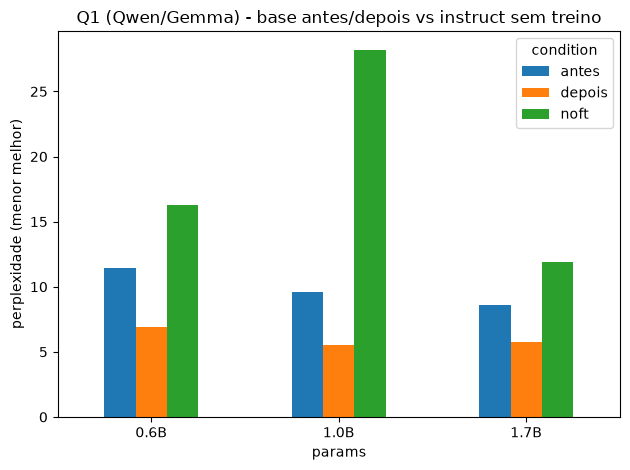

In [92]:
df = load("q1_base_vs_instruct.csv")
if df is None: skip("q1_base_vs_instruct.csv")
else:
    d = df[df.eval_set=="heldout"]
    piv = d.pivot_table(index="params", columns="condition", values="ppl", aggfunc="first")
    order = ["0.6B","1.0B","1.7B"]  # only sizes with a full antes/depois (Qwen/Gemma)
    piv = piv.reindex([x for x in order if x in piv.index])
    piv.plot(kind="bar"); plt.ylabel("perplexidade (menor melhor)")
    plt.title("Q1 (Qwen/Gemma) - base antes/depois vs instruct sem treino"); plt.xticks(rotation=0)
    plt.tight_layout(); plt.show()

## Q1 - GPT-2 (escala de ppl propria): held-out e OOD antes/depois

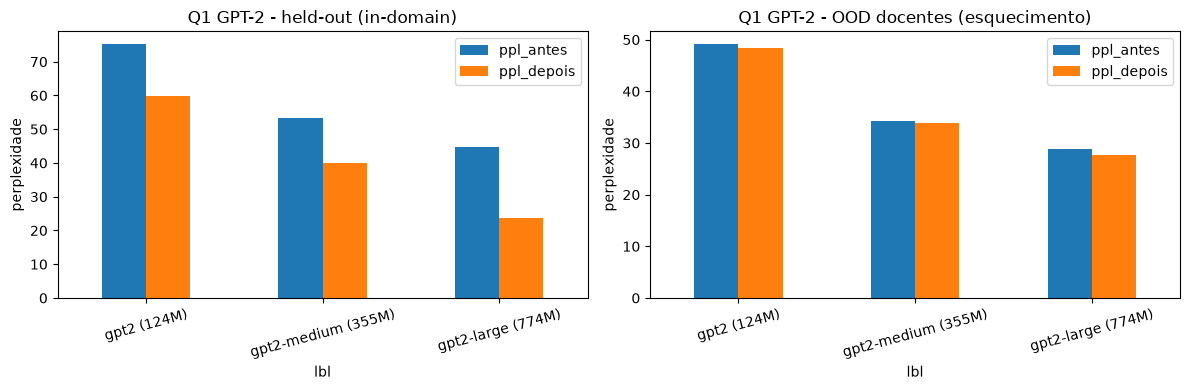

In [93]:
# GPT-2 tem tokenizer ingles, ppl absoluta nao comparavel a Qwen/Gemma; o delta
# antes/depois dentro do GPT-2 e o que importa. Le results/q1_gpt2.csv.
g = load("q1_gpt2.csv")
if g is None: skip("q1_gpt2.csv")
else:
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    for k,(s,title) in enumerate([("heldout","held-out (in-domain)"),
                                   ("ood_docentes","OOD docentes (esquecimento)")]):
        dd = g[g.eval_set==s].copy()
        dd["lbl"] = dd["model"] + " (" + dd["params"] + ")"
        dd.set_index("lbl")[["ppl_antes","ppl_depois"]].plot(kind="bar", ax=ax[k])
        ax[k].set_title(f"Q1 GPT-2 - {title}"); ax[k].set_ylabel("perplexidade")
        ax[k].tick_params(axis="x", rotation=15)
    plt.tight_layout(); plt.show()

## Q1 - Ablacao: podar licitacoes do corpus de treino (PPL)

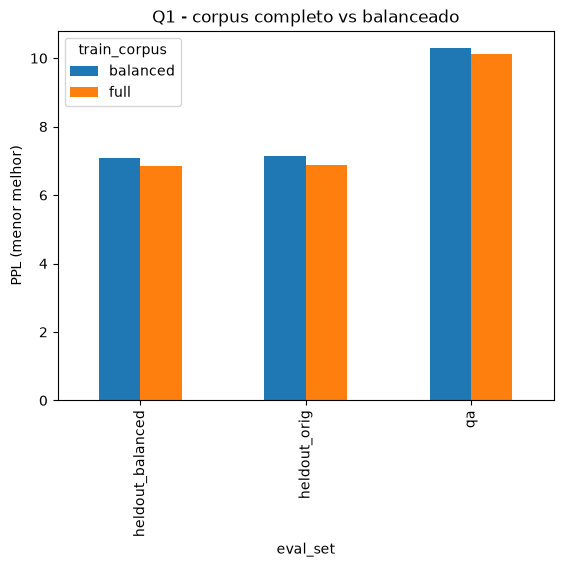

In [94]:
df = load("q1_balanceamento_licitacao.csv")
if df is None: skip("q1_balanceamento_licitacao.csv")
else:
    d = df[df.condition.isin(["depois"])].pivot_table(index="eval_set", columns="train_corpus", values="ppl", aggfunc="first")
    d.plot(kind="bar"); plt.ylabel("PPL (menor melhor)"); plt.title("Q1 - corpus completo vs balanceado")


## Q2 - SFT: nota do juiz (recall) base vs SFT vs SFT-de-Q1

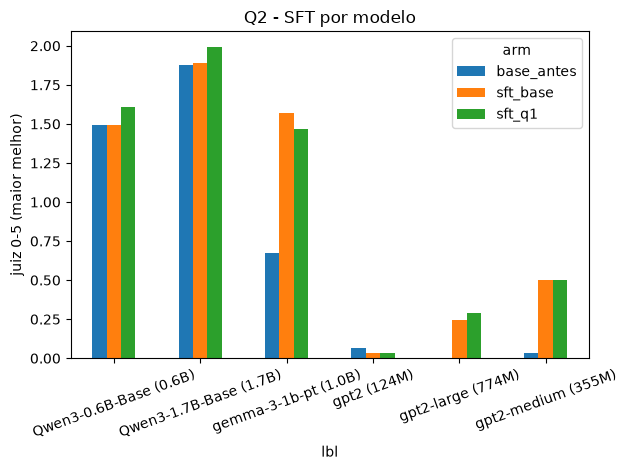

In [95]:
df = load("q2_sft.csv")
if df is None: skip("q2_sft.csv")
else:
    d = df[df.eval_set=="recall"].copy()
    d["arm"] = d.apply(lambda r: ("base_antes" if r["condition"]=="antes" else f"sft_{r['start']}"), axis=1)
    d["lbl"] = d["model"] + " (" + d["params"] + ")"
    piv = d.pivot_table(index="lbl", columns="arm", values="mean_judge", aggfunc="first")
    piv.plot(kind="bar"); plt.ylabel("juiz 0-5 (maior melhor)"); plt.title("Q2 - SFT por modelo")
    plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## Q3 - LoRA vs SFT pleno (juiz, recall)

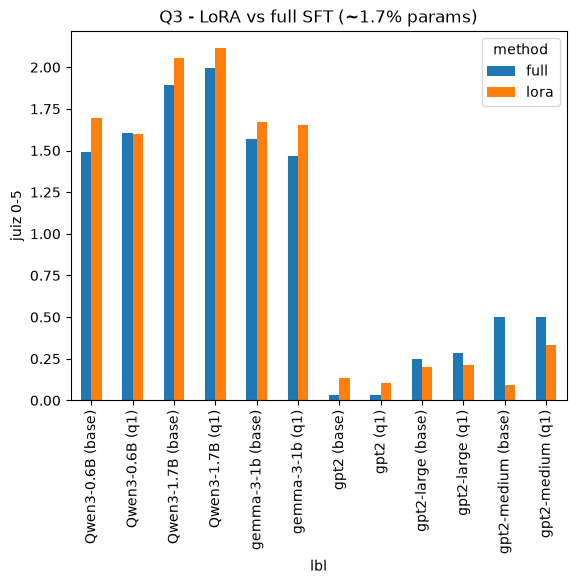

In [96]:
df = load("q3_lora.csv")
if df is None: skip("q3_lora.csv")
else:
    d = df[df.eval_set=="recall"].copy()
    d["lbl"] = d["model"]+" ("+d["start"]+")"
    piv = d.pivot_table(index="lbl", columns="method", values="mean_judge", aggfunc="first")
    piv.plot(kind="bar"); plt.ylabel("juiz 0-5"); plt.title("Q3 - LoRA vs full SFT (~1.7% params)")


## Q4 - Destilacao: base vs distill (juiz) e transfer ratio por aluno

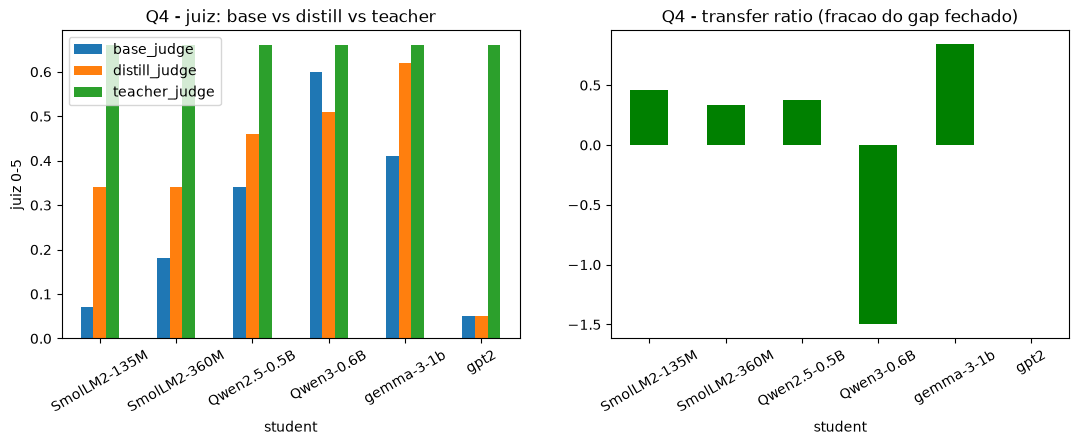

In [97]:
df = load("q4_distill.csv")
if df is None: skip("q4_distill.csv")
else:
    fig, ax = plt.subplots(1,2, figsize=(13,4))
    df.plot(x="student", y=["base_judge","distill_judge","teacher_judge"], kind="bar", ax=ax[0])
    ax[0].set_title("Q4 - juiz: base vs distill vs teacher"); ax[0].set_ylabel("juiz 0-5"); ax[0].tick_params(axis="x", rotation=30)
    df.plot(x="student", y="transfer_ratio", kind="bar", ax=ax[1], color="green", legend=False)
    ax[1].set_title("Q4 - transfer ratio (fracao do gap fechado)"); ax[1].tick_params(axis="x", rotation=30)


## Q4 - Comparacao de professores (8B/30B/27b/31b, orcamento fixo 400 pares)

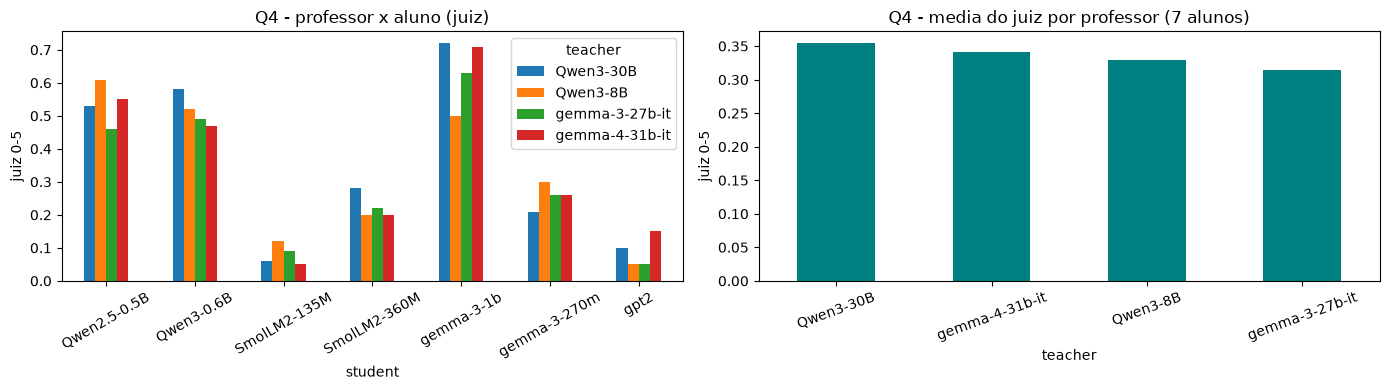

In [98]:
# Mesmo aluno e orcamento; so muda o professor. Juiz fixo Qwen3-8B no recall.
tc = load("q4_teacher_compare.csv")
if tc is None: skip("q4_teacher_compare.csv")
else:
    fig, ax = plt.subplots(1, 2, figsize=(14,4))
    piv = tc.pivot_table(index="student", columns="teacher", values="mean_judge", aggfunc="first")
    piv.plot(kind="bar", ax=ax[0]); ax[0].set_title("Q4 - professor x aluno (juiz)")
    ax[0].set_ylabel("juiz 0-5"); ax[0].tick_params(axis="x", rotation=30)
    means = tc.groupby("teacher")["mean_judge"].mean().sort_values(ascending=False)
    means.plot(kind="bar", ax=ax[1], color="teal")
    ax[1].set_title("Q4 - media do juiz por professor (7 alunos)")
    ax[1].set_ylabel("juiz 0-5"); ax[1].tick_params(axis="x", rotation=20)
    plt.tight_layout(); plt.show()

## Q5 - RAG: contribuicao por motor e modo (juiz fixo 8B; motores instruct, students destilados e gemma 4-bit)


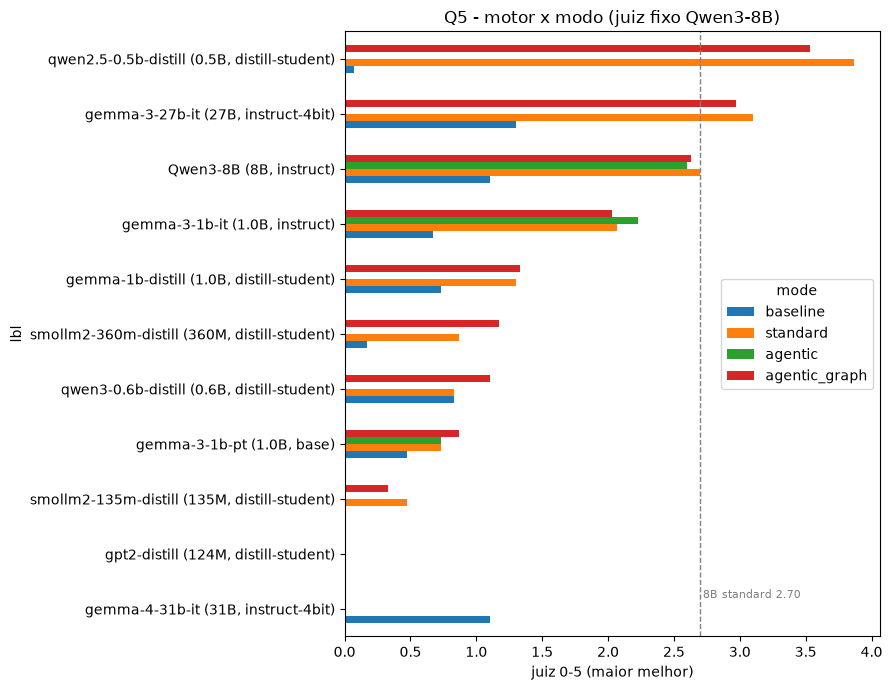

In [99]:
e = load("q5_engines.csv")
if e is None: skip("q5_engines.csv")
else:
    e = e.copy()
    e["lbl"] = e["engine"] + " (" + e["params"] + ", " + e["kind"] + ")"
    piv = e.pivot_table(index="lbl", columns="mode", values="judge", aggfunc="first")
    modes = [m for m in ["baseline", "standard", "agentic", "agentic_graph"] if m in piv.columns]
    piv = piv[modes].sort_values("standard", na_position="first")  # best standard on top; OOM/NaN at bottom
    ax = piv.plot(kind="barh", figsize=(9, 7))
    ax.set_xlabel("juiz 0-5 (maior melhor)")
    ax.set_title("Q5 - motor x modo (juiz fixo Qwen3-8B)")
    ax.axvline(2.70, ls="--", c="gray", lw=1)  # Qwen3-8B standard reference
    ax.text(2.72, 0.2, "8B standard 2.70", color="gray", fontsize=8)
    plt.tight_layout(); plt.show()

## Q6 - Guardrails: protecao com vs sem a camada (+ robustez adversarial)

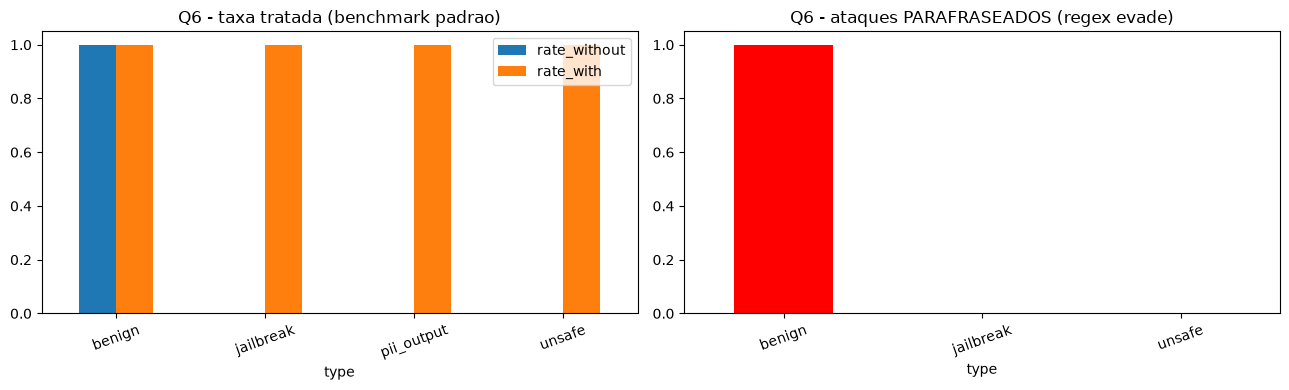

         type   n  handled_with  handled_without  rate_with  rate_without
0      benign  15            15               15        1.0           1.0
1   jailbreak   5             5                0        1.0           0.0
2  pii_output   5             5                0        1.0           0.0
3      unsafe   5             5                0        1.0           0.0


In [100]:
df = load("q6_guardrails.csv"); adv = load("q6_adversarial.csv")
if df is None: skip("q6_guardrails.csv")
else:
    fig, ax = plt.subplots(1,2, figsize=(13,4))
    df.plot(x="type", y=["rate_without","rate_with"], kind="bar", ax=ax[0])
    ax[0].set_title("Q6 - taxa tratada (benchmark padrao)"); ax[0].set_ylim(0,1.05); ax[0].tick_params(axis="x", rotation=20)
    if adv is not None:
        adv.plot(x="type", y=["rate_with"], kind="bar", ax=ax[1], color="red", legend=False)
        ax[1].set_title("Q6 - ataques PARAFRASEADOS (regex evade)"); ax[1].set_ylim(0,1.05); ax[1].tick_params(axis="x", rotation=20)
    plt.tight_layout(); plt.show(); print(df)


## Diferenciais: Q3 varredura de rank e Q2 curva de dados (rodam no node02)

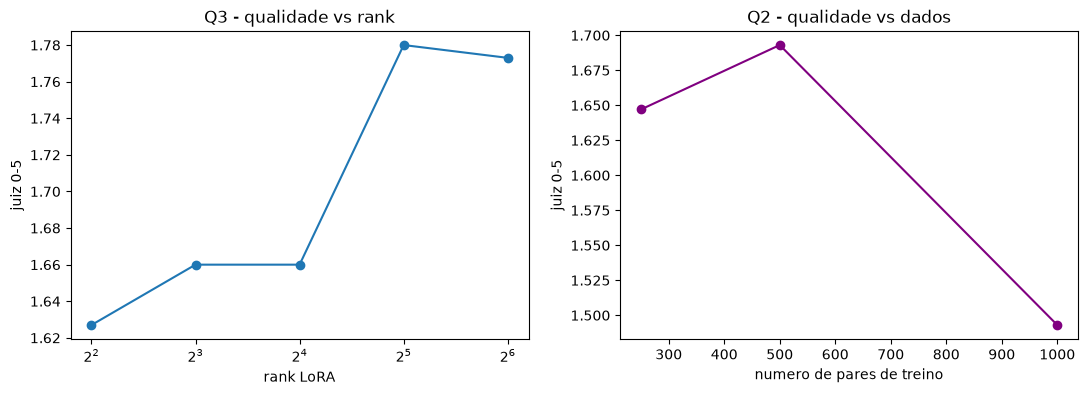

In [101]:
rk = load("q3_rank_sweep.csv"); dc = load("q2_data_curve.csv")
fig, ax = plt.subplots(1,2, figsize=(13,4))
if rk is not None:
    rk = rk.copy(); rk["r"] = rk["model"].str.extract(r"r(\d+)").astype(float)
    rk = rk.dropna(subset=["r"]).sort_values("r")
    ax[0].plot(rk["r"], rk["mean_judge"], "o-"); ax[0].set_xscale("log", base=2)
    ax[0].set_xlabel("rank LoRA"); ax[0].set_ylabel("juiz 0-5"); ax[0].set_title("Q3 - qualidade vs rank")
else: ax[0].set_title("q3_rank_sweep.csv ainda nao existe")
if dc is not None:
    dc = dc.copy(); dc["n"] = dc["model"].str.extract(r"n(\d+)").astype(float)
    dc = dc.dropna(subset=["n"]).sort_values("n")
    ax[1].plot(dc["n"], dc["mean_judge"], "o-", color="purple")
    ax[1].set_xlabel("numero de pares de treino"); ax[1].set_ylabel("juiz 0-5"); ax[1].set_title("Q2 - qualidade vs dados")
else: ax[1].set_title("q2_data_curve.csv ainda nao existe")


## Diferenciais: Q5 retrieval hit-rate@k e Q1 esquecimento (OOD)


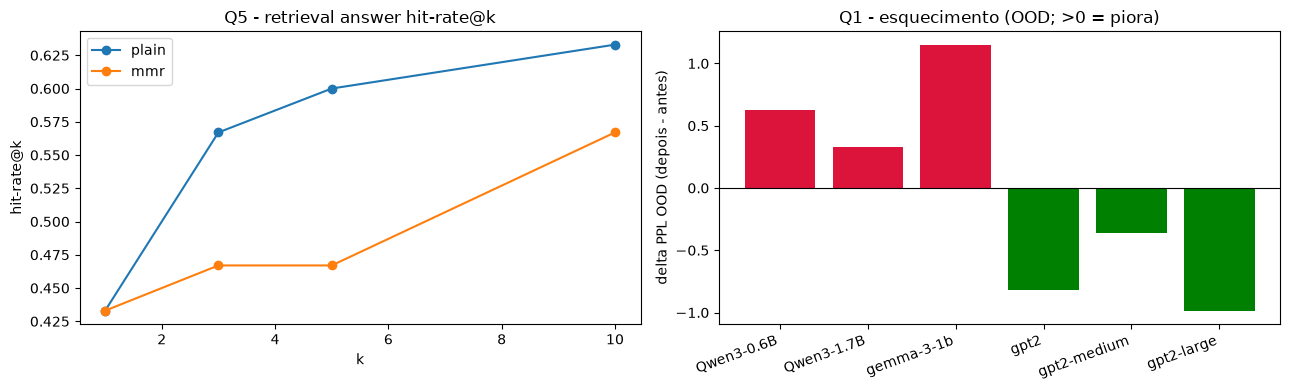

In [102]:
ret = load("q5_retrieval.csv"); fg = load("q1_forgetting.csv")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
if ret is not None:
    ks = [1, 3, 5, 10]
    for method in ["plain", "mmr"]:
        row = ret[ret["method"] == method]
        if len(row):
            ax[0].plot(ks, [row[f"hit@{k}"].iloc[0] for k in ks], "o-", label=method)
    ax[0].set_xlabel("k"); ax[0].set_ylabel("hit-rate@k")
    ax[0].set_title("Q5 - retrieval answer hit-rate@k"); ax[0].legend()
else:
    ax[0].set_title("q5_retrieval.csv ainda nao existe")
if fg is not None:
    ood = fg[fg["eval_set"] == "ood_docentes"]
    colors = ["crimson" if d > 0 else "green" for d in ood["delta_ppl"]]
    ax[1].bar(ood["model"], ood["delta_ppl"], color=colors)
    ax[1].axhline(0, color="black", lw=0.8)
    ax[1].set_ylabel("delta PPL OOD (depois - antes)")
    ax[1].set_title("Q1 - esquecimento (OOD; >0 = piora)")
    plt.setp(ax[1].get_xticklabels(), rotation=20, ha="right")
else:
    ax[1].set_title("q1_forgetting.csv ainda nao existe")
plt.tight_layout(); plt.show()
